In [55]:
import numpy as np
import matplotlib.pyplot as plt
import hcipy as hci
import pandas as pd
import utils
import time


In [56]:
t1=time.time()
time.sleep(1)
t2=time.time()
T2FInish=utils.time_asstimate(t2,t1,1,10)
print("Time asstimate to finish: "+str(int(T2FInish))+"minutes")


Time asstimate to finish: 9minutes


![Gemini_Generated_Image_jh67bjjh67bjjh67 (1).png](<attachment:Gemini_Generated_Image_jh67bjjh67bjjh67 (1).png>)

### pupil/ telescope params :
- telescope diam. 
- central obscuration : the diam. of the block in the middle of the pupil
- central obscuration ratio
- spider width : the arms/handles that hold the obscuration in place 
- oversizing factor : 

aperture params

In [57]:
wavelength = 500e-9
# wavelength = 1550e-9

# physical measurements
telescope_diameter = 8.0       # [m]
central_obscuration = 1.2      # [m]
central_obscuration_ratio = central_obscuration / telescope_diameter
spider_width = 0.05            # [m]

using the specifications to create the aperture generator :

- telescope diameter
- central obrcuration - circle in the center that is the view block of the mirror
- num spiders - the legs holding the mirror
- spider width - theyre width


In [58]:
VLT_aperture_generator = hci.make_obstructed_circular_aperture(
    telescope_diameter,
    central_obscuration_ratio,
    num_spiders=4,
    spider_width=spider_width
)

pupil grid params and instance

In [59]:
# simulation auxillary
oversizing_factor = 16.0 / 15.0
num_pupil_pixels_base = 240
num_pupil_pixels = int(num_pupil_pixels_base * oversizing_factor)  # must be int
pupil_grid_diameter = telescope_diameter * oversizing_factor
# pupil_grid = hci.make_pupil_grid(num_pupil_pixels_base, pupil_grid_diameter)
pupil_grid = hci.make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)
pupil_grid.shape

array([256, 256])

focal grid params and instance

In [60]:
q = 4
num_airy = 50
focal_spatial_resolution = wavelength / telescope_diameter
focal_grid = hci.make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=focal_spatial_resolution)
focal_grid.shape


array([400, 400])

creating an instance of an aperture field

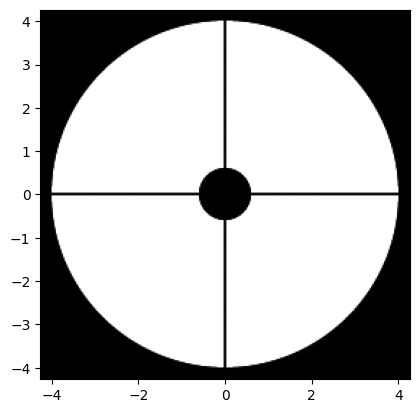

In [61]:
sampling_rate = 4
aperture = hci.evaluate_supersampled(VLT_aperture_generator,pupil_grid,4)
wf_aperture = hci.Wavefront(aperture,wavelength)
wf_aperture.total_power = 1.0
hci.imshow_field(wf_aperture.power,cmap = "gray")

propagate the wavefront through the pupil creates the psf

In [62]:
# wf_init = hci.Wavefront(np.ones_like(pupil_grid))
propagator = hci.FraunhoferPropagator(pupil_grid,focal_grid)
psf_aperture = propagator.forward(wf_aperture).power
psf_aperture.total_power = 1.0

C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:168: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_multiplications = input_grid.size * output_grid.size
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:169: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_additions = (input_grid.size - 1) * output_grid.size
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:171: RuntimeWarning: overflow encountered in scalar multiply
  num_multiplications = 4 * num_complex_multiplications
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p

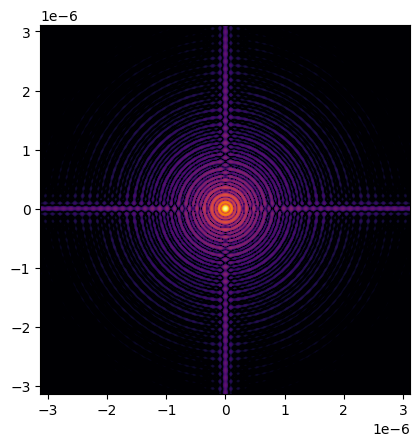

In [63]:
im = np.log10(psf_aperture/psf_aperture.max())
hci.imshow_field(im,cmap="inferno",vmin=-6,vmax=0)

atmosphere layer

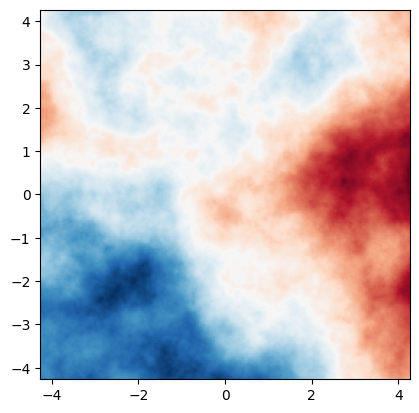

In [64]:
r0 = 2.0
wavelength_ref = 500e-9
L0 = 50.0
r0_ref_500nm = r0 * (wavelength/wavelength_ref)**(6.0/5.0)
Cn2 = hci.Cn_squared_from_fried_parameter(r0_ref_500nm,wavelength)

atmosphere = hci.InfiniteAtmosphericLayer(pupil_grid,Cn2,L0=L0,velocity=0)
phase_screen = atmosphere.phase_for(wavelength)

hci.imshow_field(phase_screen,cmap= "RdBu")

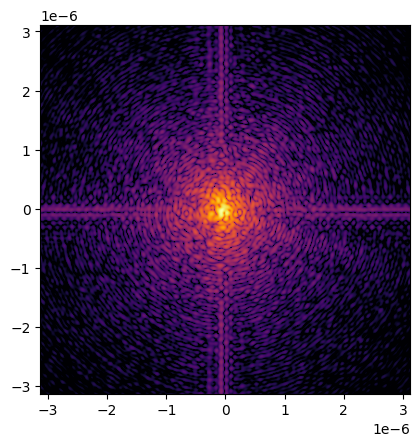

In [65]:
wf_turb = atmosphere(wf_aperture)
psf_turb = propagator.forward(wf_turb).power
psf_turb.total_power = 1.0
im = np.log10(psf_turb/psf_turb.max())
hci.imshow_field(im,cmap="inferno",vmin=-6,vmax=0)

[256 256]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15512\472173316.py:38: RuntimeWarning: invalid value encountered in log10
  hci.imshow_field(np.log10(psf1_noisy/psf1_noisy.max()),cmap="inferno",vmin=-6,vmax=0)


Text(0, 0.5, 'y[m]')

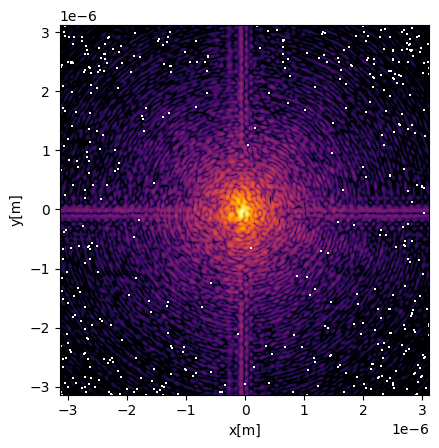

In [107]:

stellar_magnitude = 8.0
flux_zero_point = 1.5e10 
collecting_area = np.pi * (telescope_diameter/2)**2
throughput = 0.8
exposure_time = 0.01  # seconds

# Total photons/sec from the star entering the telescope
photon_flux = flux_zero_point * 10**(-0.4 * stellar_magnitude) * collecting_area * throughput

# B. Prepare the Image
# Get the intensity pattern from the wavefront (sum is usually 1.0)
image_normalized = propagator(wf_turb).power 

# Scale it to physical units (Photons / second)
image_photons_per_sec = image_normalized * photon_flux * 1000

# C. Setup the NoisyDetector
# Initialize with the grid where the image lives
detector = hci.NoisyDetector(focal_grid)

# Configure Noise Properties
detector.include_photon_noise = True
detector.read_noise = 1e-2            # rms electrons
detector.dark_current_rate = 0.001     # electrons/sec/pixel (usually low for IR)
# detector.flat_field = 0.05         # Optional: 5% pixel-to-pixel sensitivity variation

# D. Integrate and Read Out
# 1. Integrate: Accumulates photons over time 'dt'
detector.integrate(image_photons_per_sec, dt=exposure_time)

# 2. Read Out: Adds Read Noise and resets the integration bin
image_noisy = detector.read_out()

# E. Result for calculations
# image_noisy is now the 2D array of counts (electrons/ADU)
psf1_noisy = image_noisy
print(wf_turb.grid.shape)
hci.imshow_field(np.log10(psf1_noisy/psf1_noisy.max()),cmap="inferno",vmin=-6,vmax=0)
plt.title("")
plt.xlabel("x[m]")
plt.ylabel("y[m]")
# hci.imshow_field(psf1_noisy,cmap="inferno",vmin=-6,vmax=0)

In [67]:
df = pd.read_csv("./massive_output.csv")
df
cols = ["wavelength",
"r0_ref",
"run_number",

"power_in_bucket_before_turbulance",
"total_power_before_turbulance",
"precentage_before_turbulance",

"power_in_bucket_after_turbulance",
"total_power_after_turbulance",
"precentage_after_turbulance",

"time"
]
df.head()

,wavelength,r0_ref,run_number,focsl_dim,power_in_bucket_before_turbulance,total_power_before_turbulance,precentage_before_turbulance,power_in_bucket_after_turbulance,total_power_after_turbulance,precentage_after_turbulance,conservation_of_energy[%],time
0,0.000002,0.075,1,0.0005,0.573206,48.018891,0.011937,0.000844,47.925480,0.000018,99.294613,2025-11-17 14:46:08
1,0.000002,0.075,2,0.0005,0.573206,48.018891,0.011937,0.031744,47.926437,0.000662,99.296596,2025-11-17 14:46:16
2,0.000002,0.075,3,0.0005,0.573206,48.018891,0.011937,0.027454,47.926914,0.000573,99.297584,2025-11-17 14:46:24
3,0.000002,0.075,4,0.0005,0.573206,48.018891,0.011937,0.003288,47.926837,0.000069,99.297425,2025-11-17 14:46:32
4,0.000002,0.075,5,0.0005,0.573206,48.018891,0.011937,0.002483,47.926399,0.000052,99.296517,2025-11-17 14:46:43


In [68]:
df = pd.read_csv("./massive_output.csv")
r0_values = sorted([val for val in set( df["r0_ref"])] )
data = df[df["r0_ref"] == r0_values[1]]
print(r0_values,len(data))

[0.01, 0.0566666666666666, 0.075, 0.1033333333333333, 0.15] 400


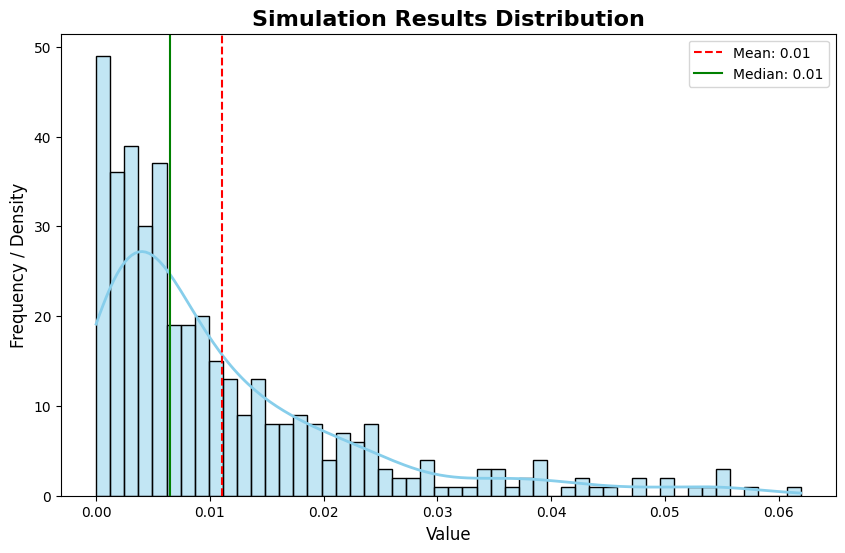

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_distribution(data, title="Data Distribution", color="skyblue", bins="auto"):
    """
    Takes an array of floats and displays its distribution using a 
    Histogram and Kernel Density Estimate (KDE).

    Parameters:
    - data: Array-like (list, numpy array, pandas series) of floats.
    - title: String for the chart title.
    - color: String for the chart color.
    - bins: Specification of hist bins, or 'auto'.
    """
    # Set the visual style
    # sns.set_theme(style="whitegrid")
    
    # Initialize the figure size
    plt.figure(figsize=(10, 6))
    
    # Create the plot (Histogram + KDE line)
    sns.histplot(data, kde=True, color=color, bins=bins, line_kws={'linewidth': 2})
    
    # Add aesthetics
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Value", fontsize=12)
    plt.ylabel("Frequency / Density", fontsize=12)
    
    # Calculate and display basic stats on the plot
    mean_val = np.mean(data)
    median_val = np.median(data)
    
    # Add vertical lines for Mean and Median
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    
    plt.legend()
    plt.show()

sample_data = np.random.normal(loc=50, scale=15, size=1000)

hyper_shape = 2
hyper_scale = 3
samples =[ np.random.gamma(hyper_shape,hyper_scale) for i in range(int(1e6))]

plot_distribution(data["power_in_bucket_after_turbulance"], title="Simulation Results Distribution",bins=50)
# plot_distribution(samples, title="Theoretical Results Distribution",bins=50)

